<img src='sharif_logo.png' alt="SUT logo" width=150 height=150 align=left class="saturate" >

<br>
<font face="Times New Roman">
<div dir=ltr align=center>
<font color=0F5298 size=7>
 Deep Learning <br>
<font color=2565AE size=5>
Computer Engineering Department - Spring 2025  <br>
<font color=3C99D size=5>
          Homework 3: Practical - Oil Price Forecasting
 <br>
<font color=696880 size=4>
            Designer: Mohammad Amanlou
    
    

# 🛢️ Oil Price Prediction using Time Series Models 📈

This notebook is designed for students to complete tasks related to oil price prediction using different machine learning models. 🚀

## 📚 References
- 📊 [Dataset: Yahoo Finance - CL=F](https://finance.yahoo.com/quote/CL=F/history/)
- 📄 [Reference Paper](https://www.ijournalse.org/index.php/ESJ/article/view/21497)

## 1️⃣ Introduction
🔍 One of the most common applications of recurrent neural networks is **time series forecasting**. In this assignment, you will predict **crude oil prices** using four different methods. 💡

## 2️⃣ Dataset and Preprocessing (25 Points)

### 📥 2.1 Download Dataset
📌 Download the dataset from **Yahoo Finance** for `CL=F` from **2010 to the present**.
[Yahoo Finance - CL=F](https://finance.yahoo.com/quote/CL=F/history/)

### 🎯 2.2 Select Features
✅ Select the `Adj Close` column as the **main feature**.

### ⚠️ **2.3 Handle Missing Data**

You will encounter missing data (`null` values) within your dataset. Follow these detailed steps carefully to handle the missing values and create a complete, reliable dataset:

#### 📝 Step 1: Introduce Random Missing Data
- Identify all indices in the `Adj Close` column that currently have valid (non-null) data.
- Set a random seed (`np.random.seed(42)`) for reproducibility.
- Randomly select **10%** of these valid indices and set their values to `NaN`.

#### 🔍 Step 2: Identify Missing Values
- Identify all dates where at least one column has a missing value (`NaN`).
- Print the number of missing dates and the total number of dates to evaluate the extent of missingness.

#### 🔧 Step 3: Replace Missing Values
- Create a copy of the `Adj Close` column for filling purposes.
- First, apply **linear interpolation** to estimate missing values based on surrounding data points.
- Then, use backward fill (`bfill`) followed by forward fill (`ffill`) methods to handle any remaining missing values at the start or end of the dataset.

#### 🎯 Outcome:
After completing these steps, your dataset will have no missing values in the `Adj Close` column, ready for further analysis or modeling.

🛠 *Your task:* Implement the missing data handling methods below. (16 Points)

In [ ]:
!pip install numpy==1.24.4

In [ ]:
!pip install --upgrade yfinance

In [ ]:
import yfinance as yf
import pandas as pd

# TO Do: Read the data and pring 5 examples

data = yf.download('CL=F', start='2010-01-01', end='2025-05-04', auto_adjust=False)

# Select the 'Adj Close' column as the main feature
adj_close_data = data[['Adj Close']]

# Reset the index to replace dates with numeric indices (0, 1, 2, 3,...)
adj_close_data.reset_index(drop=True, inplace=True)

# Display the first 5 rows of the dataset
print(adj_close_data.head())

[*********************100%***********************]  1 of 1 completed

Price   Adj Close
Ticker       CL=F
0       81.510002
1       81.769997
2       83.180000
3       82.660004
4       82.750000


In [ ]:
# TO DO: Introduce random null

import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Identify valid (non-null) indices in the 'Adj Close' column
valid_indices = adj_close_data[adj_close_data['Adj Close'].notnull()].index

# Randomly select 10% of valid indices and set their values to NaN
missing_indices = np.random.choice(valid_indices, size=int(len(valid_indices) * 0.1), replace=False)

# Set the selected indices to NaN
adj_close_data.loc[missing_indices, 'Adj Close'] = np.nan


In [ ]:
# TO DO: Identify missing dates and null values

# Identify all dates where there is at least one missing value (NaN)
missing_dates = adj_close_data[adj_close_data.isnull().any(axis=1)].index

# Calculate the number of missing dates and total dates
num_missing_dates = len(missing_dates)
num_all_dates = len(adj_close_data)

# Print the result
print(f"Num of missing dates: {num_missing_dates}")
print(f"Num of all dates: {num_all_dates}")



Num of missing dates: 385
Num of all dates: 3856


In [ ]:
# TO DO: Fill missing values using .interpolate or .fillna(method='bfill').fillna(method='ffill')

# Create a copy of the 'Adj Close' column for filling
adj_close_filled = adj_close_data['Adj Close'].copy()

# Step 1: Apply linear interpolation to estimate missing values
adj_close_filled = adj_close_filled.interpolate(method='linear')

# Step 2: Use backward fill (bfill) and then forward fill (ffill) to handle any remaining missing values
adj_close_filled = adj_close_filled.fillna(method='bfill').fillna(method='ffill')

# Update the original dataset with the filled values
adj_close_data['Adj Close'] = adj_close_filled




<ipython-input-6-d5d800309fa0>:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  adj_close_filled = adj_close_filled.fillna(method='bfill').fillna(method='ffill')
<ipython-input-6-d5d800309fa0>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adj_close_data['Adj Close'] = adj_close_filled




```
# This is formatted as code
```

### ✂️ 2.4 Train-Test Split and Normalization
- **Split** the dataset into **training and test sets** based on the ratio given in the reference paper.
- **Normalize** the data.

📄 [Reference Paper](https://www.ijournalse.org/index.php/ESJ/article/view/21497)

🛠 *Your task:* Implement the splitting and normalization below. (4 Points)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

def temporal_split(series, train_ratio=0.6, val_ratio=0.2):
    total_samples = len(series)
    train_size = int(total_samples * train_ratio)
    remaining_size = total_samples - train_size
    val_size = int(remaining_size * val_ratio)

    # Define the splits based on the indices
    train = series[:train_size]
    val = series[train_size:train_size + val_size]
    test = series[train_size + val_size:]

    return train, val, test

train_list, val_list, test_list = [], [], []

# Split the data using temporal split
train, val, test = temporal_split(adj_close_data)
train_list.append(train)
val_list.append(val)
test_list.append(test)

train_data = pd.concat(train_list)
val_data = pd.concat(val_list)
test_data = pd.concat(test_list)

# Initialize the scaler
scaler = MinMaxScaler()

# Fit the scaler on the training data
train_data['Adj Close'] = scaler.fit_transform(train_data[['Adj Close']])

# Transform the validation and test data using the same scaler
val_data['Adj Close'] = scaler.transform(val_data[['Adj Close']])
test_data['Adj Close'] = scaler.transform(test_data[['Adj Close']])

# Print the sample of training and testing data
print("Training data sample:")
print(train_data.head())
print("Testing data sample:")
print(test_data.head())


Training data sample:
Price  Adj Close
Ticker      CL=F
0       0.628977
1       0.631952
2       0.648089
3       0.642138
4       0.643168
Testing data sample:
Price  Adj Close
Ticker      CL=F
2621    0.148775
2622    0.145285
2623    0.141794
2624    0.149348
2625    0.112039


### 📊 2.5 Data Visualization
- **Plot a histogram** similar to **Figure 6** in the reference paper, showing the **distribution of oil prices**.

🛠 *Your task:* Implement the histogram plot below. (5 Points)

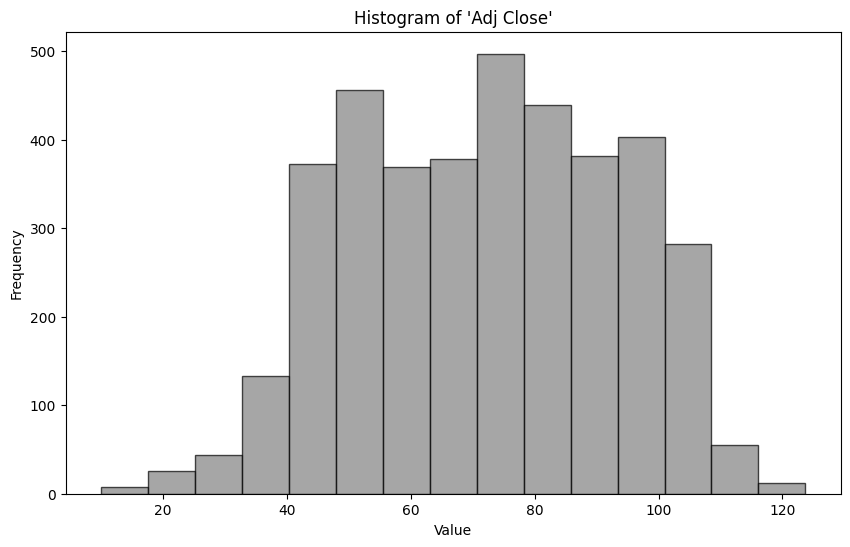

In [ ]:
# TO DO: Plot histogram of 'Adj Close'
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(adj_close_data['Adj Close'], bins=15, color='gray', edgecolor='black', alpha=0.7)
plt.title("Histogram of 'Adj Close'")
plt.xlabel('Value')
plt.ylabel('Frequency')
#plt.grid(True)
plt.show()

## 3️⃣ Implementing Deep Learning Models 🤖 (60 Points)

The reference paper utilizes **three models** for time series forecasting:
- `RNN`
- `LSTM`
- `GRU`

📌 **Train** each model using the **hyperparameters** given in **Table 4** of the paper.
📌 Use `Mean Square Error (MSE)` as the **loss function**.

📄 [Reference Paper](https://www.ijournalse.org/index.php/ESJ/article/view/21497)


### Important Details & Clarifications

- **What to Predict?**  
  The goal is to predict **the actual next-day price** (regression problem), rather than just identifying price increase or decrease.
  
- **Input/Output Structure:**  
  - **Input:** A window of \( k \) consecutive daily prices (e.g., 50 days).  
  - **Output:** The predicted price for the next day.
  
- **How to Evaluate?**  
  Use the four metrics (RMSE, MAE, MAPE, \( R^2 \)) to gauge how accurately your model tracks the real price values.

- **Target Accuracy:**  
  Your accuracy might differ from the paper’s due to factors like data splitting, normalization, or different random seeds. However, aim to closely replicate the paper’s results or provide justifications for any discrepancy.

**Final Deliverables:**
1. **All four trained models** (RNN, LSTM, GRU).  
2. **Comparison plots** of predicted vs. actual values (in both normalized and original price scales, if desired).  
3. **Performance metrics** (RMSE, MAE, MAPE, \( R^2 \)) for each model, presented in a table or a concise summary.


🛠 *Your task:* Implement these models below. (30 Points)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

def create_sequences(data, window_size):
    sequences = []
    labels = []
    for i in range(len(data) - window_size):
        seq = data[i:i+window_size]
        label = data[i+window_size]
        sequences.append(seq)
        labels.append(label)
    return np.array(sequences), np.array(labels)

window_size = 50
#TO DO: make test and train loader

# Prepare the sequence data from normalized training and test sets
train_seq, train_labels = create_sequences(train_data['Adj Close'].values, window_size)
test_seq, test_labels = create_sequences(test_data['Adj Close'].values, window_size)

# Convert to PyTorch tensors
train_seq_tensor = torch.tensor(train_seq, dtype=torch.float32).unsqueeze(-1)
train_labels_tensor = torch.tensor(train_labels, dtype=torch.float32).unsqueeze(-1)
test_seq_tensor = torch.tensor(test_seq, dtype=torch.float32).unsqueeze(-1)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.float32).unsqueeze(-1)

# Create TensorDatasets
train_dataset = TensorDataset(train_seq_tensor, train_labels_tensor)
test_dataset = TensorDataset(test_seq_tensor, test_labels_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)


In [ ]:
# LSTM
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=512, num_layers=1, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        if x.dim() == 4:
          x = x.squeeze(-1)

        # Initialize hidden state and cell state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))  # out: (batch, seq_len, hidden)
        out = out[:, -1, :]              # get the output of the last time step
        out = self.fc(out)
        return out

lstm_model = LSTMModel()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

def train_model(model, train_loader, test_loader, epochs=50):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(x_batch)
            loss = loss_fn(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

train_model(lstm_model, train_loader, test_loader)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([100, 1, 1])) that is different to the input size (torch.Size([100, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/loss.py:610: UserWarning: Using a target size (torch.Size([63, 1, 1])) that is different to the input size (torch.Size([63, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1/50, Loss: 0.1418
Epoch 2/50, Loss: 0.1167
Epoch 3/50, Loss: 0.0987
Epoch 4/50, Loss: 0.0597
Epoch 5/50, Loss: 0.0613
Epoch 6/50, Loss: 0.0435
Epoch 7/50, Loss: 0.0432
Epoch 8/50, Loss: 0.0269
Epoch 9/50, Loss: 0.0171
Epoch 10/50, Loss: 0.0302
Epoch 11/50, Loss: 0.0194
Epoch 12/50, Loss: 0.0097
Epoch 13/50, Loss: 0.0113
Epoch 14/50, Loss: 0.0138
Epoch 15/50, Loss: 0.0108
Epoch 16/50, Loss: 0.0111
Epoch 17/50, Loss: 0.0117
Epoch 18/50, Loss: 0.0108
Epoch 19/50, Loss: 0.0103
Epoch 20/50, Loss: 0.0101
Epoch 21/50, Loss: 0.0100
Epoch 22/50, Loss: 0.0100
Epoch 23/50, Loss: 0.0099
Epoch 24/50, Loss: 0.0099
Epoch 25/50, Loss: 0.0100
Epoch 26/50, Loss: 0.0100
Epoch 27/50, Loss: 0.0100
Epoch 28/50, Loss: 0.0100
Epoch 29/50, Loss: 0.0100
Epoch 30/50, Loss: 0.0100
Epoch 31/50, Loss: 0.0100
Epoch 32/50, Loss: 0.0099
Epoch 33/50, Loss: 0.0099
Epoch 34/50, Loss: 0.0099
Epoch 35/50, Loss: 0.0099
Epoch 36/50, Loss: 0.0098
Epoch 37/50, Loss: 0.0098
Epoch 38/50, Loss: 0.0098
Epoch 39/50, Loss: 0.

In [ ]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=512, num_layers=1, output_size=1):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        if x.dim() == 4:
          x = x.squeeze(-1)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = out[:, -1, :]
        return self.fc(out)

rnn_model = RNNModel()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
train_model(rnn_model, train_loader, test_loader)


Epoch 1/50, Loss: 0.0806
Epoch 2/50, Loss: 4.9220
Epoch 3/50, Loss: 0.1334
Epoch 4/50, Loss: 0.5668
Epoch 5/50, Loss: 0.2423
Epoch 6/50, Loss: 0.0467
Epoch 7/50, Loss: 0.0892
Epoch 8/50, Loss: 0.1241
Epoch 9/50, Loss: 0.0695
Epoch 10/50, Loss: 0.0316
Epoch 11/50, Loss: 0.0616
Epoch 12/50, Loss: 0.1200
Epoch 13/50, Loss: 0.1491
Epoch 14/50, Loss: 0.0592
Epoch 15/50, Loss: 0.0670
Epoch 16/50, Loss: 0.1522
Epoch 17/50, Loss: 0.2279
Epoch 18/50, Loss: 0.0689
Epoch 19/50, Loss: 0.4062
Epoch 20/50, Loss: 1.0770
Epoch 21/50, Loss: 0.3197
Epoch 22/50, Loss: 0.0820
Epoch 23/50, Loss: 0.0564
Epoch 24/50, Loss: 0.0860
Epoch 25/50, Loss: 0.1692
Epoch 26/50, Loss: 0.0491
Epoch 27/50, Loss: 0.0676
Epoch 28/50, Loss: 0.0833
Epoch 29/50, Loss: 0.0584
Epoch 30/50, Loss: 0.0683
Epoch 31/50, Loss: 0.0893
Epoch 32/50, Loss: 0.0423
Epoch 33/50, Loss: 0.0598
Epoch 34/50, Loss: 0.0993
Epoch 35/50, Loss: 0.0346
Epoch 36/50, Loss: 0.0449
Epoch 37/50, Loss: 0.0832
Epoch 38/50, Loss: 0.0583
Epoch 39/50, Loss: 0.

In [ ]:
# GRU
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=512, num_layers=1, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        if x.dim() == 4:
          x = x.squeeze(-1)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = out[:, -1, :]
        return self.fc(out)

gru_model = GRUModel()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)
train_model(gru_model, train_loader, test_loader)

Epoch 1/50, Loss: 0.0845
Epoch 2/50, Loss: 0.0865
Epoch 3/50, Loss: 0.0719
Epoch 4/50, Loss: 0.0309
Epoch 5/50, Loss: 0.0175
Epoch 6/50, Loss: 0.0107
Epoch 7/50, Loss: 0.0138
Epoch 8/50, Loss: 0.0152
Epoch 9/50, Loss: 0.0121
Epoch 10/50, Loss: 0.0113
Epoch 11/50, Loss: 0.0113
Epoch 12/50, Loss: 0.0111
Epoch 13/50, Loss: 0.0110
Epoch 14/50, Loss: 0.0107
Epoch 15/50, Loss: 0.0105
Epoch 16/50, Loss: 0.0104
Epoch 17/50, Loss: 0.0102
Epoch 18/50, Loss: 0.0101
Epoch 19/50, Loss: 0.0099
Epoch 20/50, Loss: 0.0097
Epoch 21/50, Loss: 0.0096
Epoch 22/50, Loss: 0.0095
Epoch 23/50, Loss: 0.0094
Epoch 24/50, Loss: 0.0093
Epoch 25/50, Loss: 0.0091
Epoch 26/50, Loss: 0.0089
Epoch 27/50, Loss: 0.0087
Epoch 28/50, Loss: 0.0085
Epoch 29/50, Loss: 0.0083
Epoch 30/50, Loss: 0.0082
Epoch 31/50, Loss: 0.0080
Epoch 32/50, Loss: 0.0079
Epoch 33/50, Loss: 0.0079
Epoch 34/50, Loss: 0.0080
Epoch 35/50, Loss: 0.0079
Epoch 36/50, Loss: 0.0078
Epoch 37/50, Loss: 0.0078
Epoch 38/50, Loss: 0.0080
Epoch 39/50, Loss: 0.

### 📈 3.1 Prediction and Evaluation
1. **Prediction:** After training, generate predictions for the test set (i.e., predict the next-day price based on the preceding \( k \) days).
2. **Visualization:** **Plot the predicted values** alongside the **actual values** for each model. This comparison helps in visually assessing each model’s performance.

🛠 **Your Task:** Implement the **visualization of predictions** (15 Points).

In [ ]:
# Predictions
def predict(model, data_loader):
    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
      for x_batch, y_batch in data_loader:
          y_pred = model(x_batch)
          predictions.append(y_pred.squeeze().cpu().numpy())
          actuals.append(y_batch.squeeze().cpu().numpy())
    return np.concatenate(predictions), np.concatenate(actuals)

#TO DO: predict real outputs
lstm_preds, lstm_targets = predict(lstm_model, test_loader)
rnn_preds, rnn_targets = predict(rnn_model, test_loader)
gru_preds, gru_targets = predict(gru_model, test_loader)

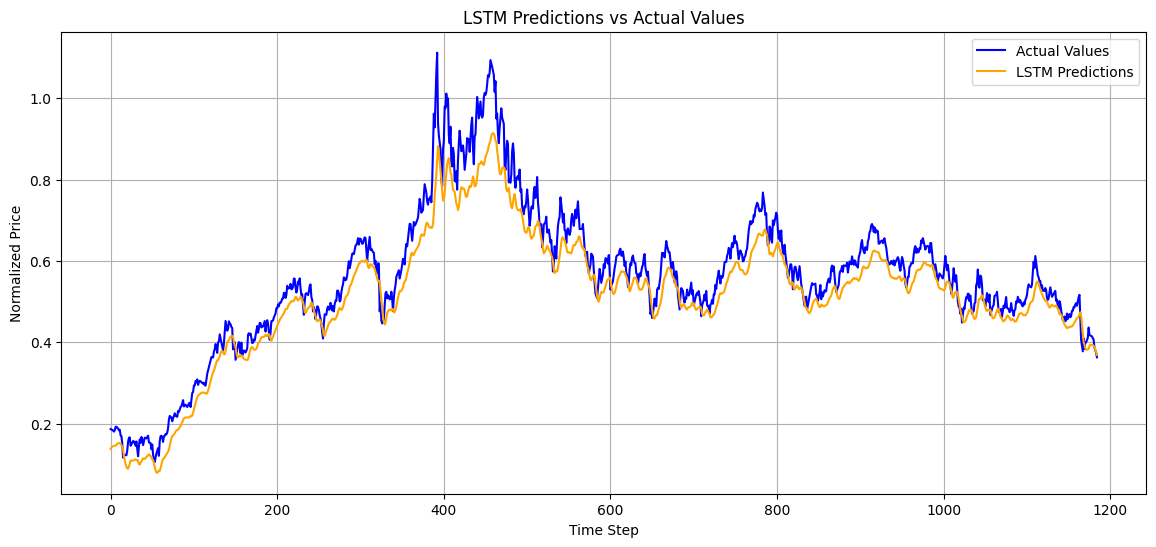

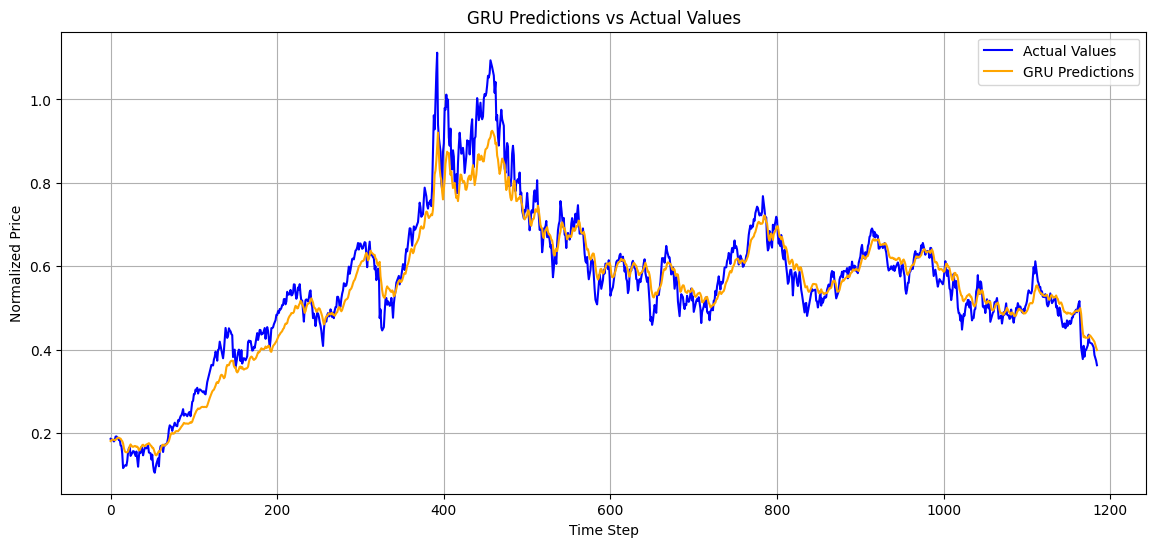

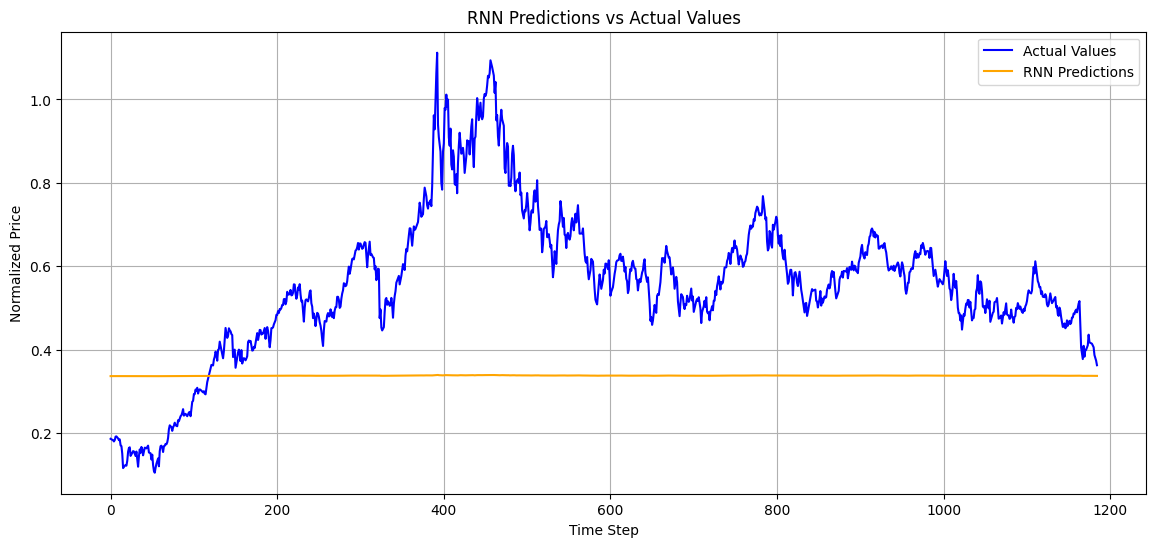

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(predictions, actual, model_name):
    plt.figure(figsize=(14, 6))
    plt.plot(actual, label="Actual Values", color='blue')
    plt.plot(predictions, label=f"{model_name} Predictions", color='orange')
    plt.title(f"{model_name} Predictions vs Actual Values")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Price")
    plt.legend()
    plt.grid(True)
    plt.show()

#TO DO: plot all models predictions on all data

plot_predictions(lstm_preds, lstm_targets, "LSTM")
plot_predictions(gru_preds, gru_targets, "GRU")
plot_predictions(rnn_preds, rnn_targets, "RNN")

### 📊 3.2 Error Metrics
📌 Explain the following **error metrics** used in the paper:
- `RMSE` (Root Mean Square Error)

  Measures the square root of the average squared differences between predicted and actual values.  
    It penalizes larger errors more than smaller ones, making it sensitive to outliers.  
    ➤ Lower RMSE = better performance.  
    
    **Formula:**  
    
  $$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
  
- `MAE` (Mean Absolute Error)

  Measures the average of the absolute differences between predicted and actual values.  
  It treats all errors equally and is more robust to outliers.  
  ➤ Lower MAE = better accuracy.
  
  **Formula:**  
  
  $$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$


- `MAPE` (Mean Absolute Percentage Error)

  Measures the average absolute percentage difference between predicted and actual values.  
  Expresses error as a percentage, making it easier to interpret.  
  ➤ Lower MAPE = better model, but it may be unstable when actual values are close to zero.
  
  **Formula:**  
  
  $$\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$
- `R-Squared` (Coefficient of Determination)

  Indicates how well the model explains the variance in the actual data.  
  Ranges from 0 (no explanatory power) to 1 (perfect prediction).  
  ➤ Higher R² = better model fit.
  
  **Formula:**  
  
  $$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}$$

**📌 Instruction:**  
Explain each of these error metrics and calculate them for **each model** (RNN, LSTM, GRU). Compare your results with the paper’s findings to see how closely they match.

### 📊 Comparison of Evaluation Metrics: Our Models vs. Paper Results

| Model      | MAE       | RMSE      | R²       | MAPE (%) | Source         |
|------------|-----------|-----------|----------|-----------|----------------|
| **RNN**    | 0.2463    | 0.2821    | -1.4959  | 44.8800   | Ours           |
| **LSTM**   | 0.0465    | 0.0576    | 0.8961   | 8.8601    | Ours           |
| **GRU**    | 0.0326    | 0.0446    | 0.9376   | 6.1914    | Ours           |
| **LSTM**   | 667.6389  | 896.7875  | 0.9425   | 3.9412    | Paper          |
| **GRU**    | 531.0581  | 718.0000  | 0.9631   | 3.0547    | Paper          |


🛠 *Your task:* Implement the evaluation metrics below. (15 Points)

In [ ]:
# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def calculate_metrics(predictions, actual):
    mae = mean_absolute_error(actual, predictions)
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100
    r2 = r2_score(actual, predictions)
    return {
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "MAPE (%)": round(mape, 4),
        "R^2": round(r2, 4)
    }

print("RNN Metrics (Unscaled):", calculate_metrics(rnn_preds, rnn_targets))
print("LSTM Metrics (Unscaled):", calculate_metrics(lstm_preds, lstm_targets))
print("GRU Metrics (Unscaled):", calculate_metrics(gru_preds, gru_targets))

RNN Metrics (Unscaled): {'MAE': 0.2463, 'RMSE': 0.2821, 'MAPE (%)': 44.88, 'R^2': -1.4959}
LSTM Metrics (Unscaled): {'MAE': 0.0465, 'RMSE': 0.0576, 'MAPE (%)': 8.8601, 'R^2': 0.8961}
GRU Metrics (Unscaled): {'MAE': 0.0326, 'RMSE': 0.0446, 'MAPE (%)': 6.1914, 'R^2': 0.9376}


In [ ]:
# Fill missing values for all features
filled_data = data.copy()
for column in ['Open', 'High', 'Low', 'Volume', 'Adj Close']:
    filled_data[column] = (
    filled_data[column]
    .interpolate(method='linear')
    .bfill()
    .ffill()
)

# WE WILL USE THESE IN ARIMA PART AS INPUTS OF MODELS
train_data = filled_data.iloc[:-int(0.3 * len(filled_data))]
test_data = filled_data.iloc[-int(0.3 * len(filled_data)):]
train_target = train_data['Adj Close']
train_exog = train_data[['Open', 'High', 'Low', 'Volume']]
test_exog = test_data[['Open', 'High', 'Low', 'Volume']]

# ADF Test
from statsmodels.tsa.stattools import adfuller
result = adfuller(train_data['Adj Close'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print(f"Critical Values: {result[4]}")
print("The series is stationary." if result[1] < 0.05 else "The series is not stationary.")

ADF Statistic: -1.3122334153923312
p-value: 0.623557092697516
Critical Values: {'1%': -3.432777869877464, '5%': -2.8626126542965666, '10%': -2.567341009611998}
The series is not stationary.


## 4️⃣ ARIMA Model 📉 (15 Points)

📌 Explain the **difference** between `ARIMA` and `SARIMA` models.

  - **ARIMA (AutoRegressive Integrated Moving Average)** is a time series model used for forecasting non-seasonal data by combining:
  - AR (AutoRegression): relationship between an observation and its past values.
  - I (Integration): differencing the data to make it stationary.
  - MA (Moving Average): relationship between an observation and residual errors from a moving average model applied to lagged observations.

- **SARIMA (Seasonal ARIMA)** extends ARIMA by adding support for **seasonal patterns** in the data.  
  SARIMA includes **seasonal AR**, **seasonal MA**, **seasonal differencing**, and a **seasonal period** parameter (usually 12 for monthly data, 4 for quarterly).

> 🧠 **Key Difference:** SARIMA = ARIMA + Seasonal Terms

📌 List the **advantages** and **limitations** of `ARIMA`.

**✅ Advantages:**
- Effective for **univariate** time series forecasting.
- Well-understood, interpretable with **clear mathematical foundation**.
- Handles both trend and noise.
- Widely used in econometrics and finance.

**❌ Limitations:**
- Assumes **linearity**; not suitable for nonlinear time series.
- Requires **stationary data** (needs preprocessing via differencing).
- Struggles with **seasonality** unless extended (via SARIMA).
- Poor at **long-term forecasting** due to reliance on recent lags.

📌 Explain the **mathematical formulation** of `ARIMA`, including its **parameters**.

**Notation:** ARIMA(**p**, **d**, **q**)  
Where:  
- `p` = number of autoregressive (AR) terms  
- `d` = number of differencing operations to make the series stationary  
- `q` = number of moving average (MA) terms  

**General Equation:**

Let $ y_t $ be the original time series.

- **Differencing (order d):**
  $$
  y'_t = y_t - y_{t-1} \quad \text{(for d=1)}
  $$

- **AR (AutoRegressive) part:**
  $$
  y'_t = \phi_1 y'_{t-1} + \phi_2 y'_{t-2} + \dots + \phi_p y'_{t-p}
  $$

- **MA (Moving Average) part:**
  $$
  + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \dots + \theta_q \varepsilon_{t-q} + \varepsilon_t
  $$

- **Full ARIMA(p, d, q) model:**
  $$
  y_t = \text{AR terms} + \text{MA terms} + \text{random error}
  $$

Where:
- $ \phi $ are AR coefficients,
- $ \theta $ are MA coefficients,
- $ \varepsilon_t $ is white noise.

📌 Determine the **optimal parameters** for `ARIMA` and **report the results**.

    Optimal ARIMA Order: (4, 1, 2)
    Metrics (Unscaled): (1.0519, 1.4914, 1.6121, 0.9951)

📌 Compare the results with **Table 6** from the paper.

### 📊 ARIMA Model Comparison: Ours vs. Paper

| ARIMA Order      | MAE       | RMSE      | R²       | MAPE (%) | Source         |
|------------------|-----------|-----------|----------|-----------|----------------|
| **(4,1,2)**       | 1.0519    | 1.4914    | 1.6121   | 0.9951    | Ours           |
| **(1,1,5)**       | 4700.3681 | 5817.1785 | -0.0110  | 35.9599   | Paper      |
| **(2,2,2)**       | 4898.0502 | 5922.1584 | -0.0476  | 36.6571   | Paper      |


📄 [Reference Paper](https://www.ijournalse.org/index.php/ESJ/article/view/21497)

🛠 *Your task:* Implement the ARIMA model below.

In [ ]:
!pip uninstall -y pmdarima
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.1 MB/s eta 0:00:00


In [ ]:
# Train ARIMA model using auto_arima
!pip install pmdarima
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
import yfinance as yf
import pandas as pd
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")


# Make sure to drop NaNs if any remain
arima_series = adj_close_data['Adj Close'].dropna()


#TO DO:Find optimal arima model using auto_arima

arima_model = auto_arima(arima_series, seasonal=False, trace=True,
                         stepwise=True, suppress_warnings=True,
                         error_action='ignore', approximation=False)

print(f"Optimal ARIMA Order: {arima_model.order}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=14005.197, Time=1.81 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14014.573, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14011.921, Time=0.15 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14011.543, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14012.637, Time=0.08 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=14009.034, Time=1.77 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=14008.952, Time=2.21 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=14002.205, Time=9.93 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=14004.270, Time=4.42 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=13997.800, Time=14.87 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=14003.720, Time=3.29 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=14003.558, Time=4.23 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=14002.064, Time=7.61 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=14002.644, Time=4.40 sec
 ARIMA(5,1,1)(0,0,

In [ ]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from tqdm import tqdm
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
warnings.filterwarnings("ignore", category=ConvergenceWarning, module="statsmodels")

#TO DO: Predinct Arima outputs

window_size = 50
series = adj_close_data['Adj Close'].dropna().values
arima_preds = []
actual_vals = []

print("Processing ARIMA predictions:")
for i in tqdm(range(window_size, len(series))):
    train_window = series[i - window_size:i]
    actual_val = series[i]

    try:
        model = ARIMA(train_window, order=arima_model.order)
        model_fit = model.fit()
        forecast = model_fit.forecast()[0]
        scalar_forecast = float(forecast[0])

    except:
        scalar_forecast = train_window[-1]  # fallback if model fails

    arima_preds.append(scalar_forecast)
    actual_vals.append(actual_val)

# Convert to numpy arrays for metrics
arima_preds = np.array(arima_preds)
actual_vals = np.array(actual_vals)

# Calculate and print metrics
arima_metrics = calculate_metrics(arima_preds, actual_vals)
print("ARIMA Metrics (Unscaled):", tuple(arima_metrics.values()))

Processing ARIMA predictions:


100%|██████████| 3806/3806 [15:07<00:00,  4.20it/s]

ARIMA Metrics (Unscaled): (1.0519, 1.4914, 1.6121, 0.9951)


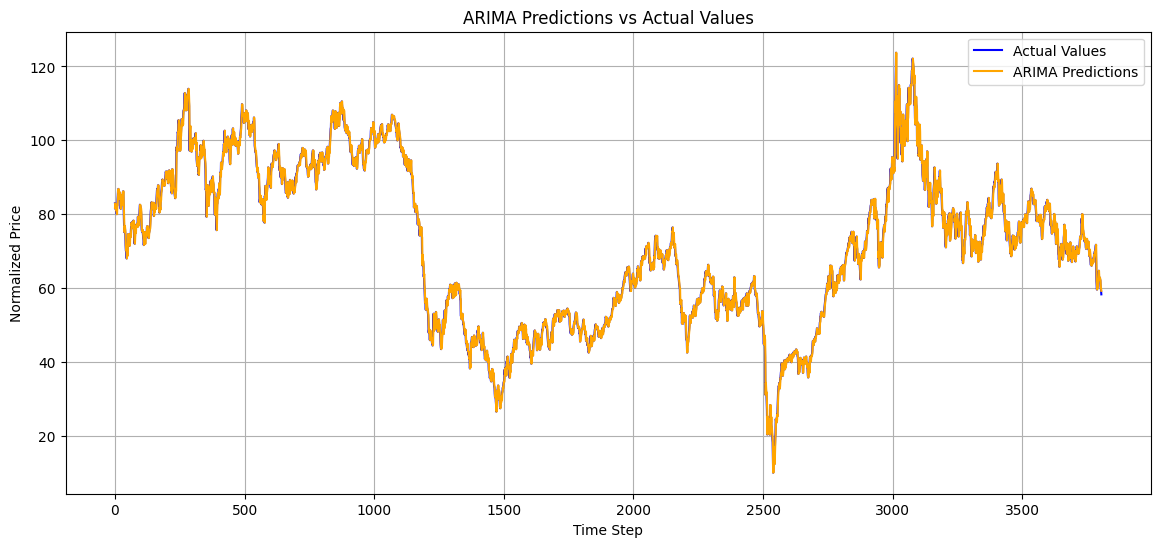

In [ ]:
#TO DO: Plot ARIMA vs actual
plot_predictions(arima_preds, actual_vals, "ARIMA")

In [ ]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
order_combinations = [(3,1,2)]
seasonal_combinations = [(3,1,1,12)]
# Initialize variables to store the best results
best_aic = float("inf")
best_order = None
best_seasonal_order = None
best_model = None

# Grid search over all parameter combinations
for order in order_combinations:
    for seasonal_order in seasonal_combinations:
        try:
            #TO DO: Train SARIMA model
            # Train SARIMA model
            model = SARIMAX(adj_close_data['Adj Close'], order=order, seasonal_order=seasonal_order)
            model_fit = model.fit(disp=False)

            #TO DO: Check AIC
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = order
                best_seasonal_order = seasonal_order
                best_model = model_fit

        except Exception as e:
            print(e)
            continue

print(f"Best SARIMA Model: Order={best_order}, Seasonal_Order={best_seasonal_order}, AIC={best_aic}")
print(best_model.summary())

Best SARIMA Model: Order=(3, 1, 2), Seasonal_Order=(3, 1, 1, 12), AIC=14027.736817729805
                                      SARIMAX Results                                       
Dep. Variable:                                 CL=F   No. Observations:                 3856
Model:             SARIMAX(3, 1, 2)x(3, 1, [1], 12)   Log Likelihood               -7003.868
Date:                              Sat, 10 May 2025   AIC                          14027.737
Time:                                      18:02:26   BIC                          14090.277
Sample:                                           0   HQIC                         14049.951
                                             - 3856                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1    

In [ ]:
#TO DO: Batch forecasting for SARIMA

# Define the forecast range
start_idx = 0
end_idx = len(adj_close_data) - 1

# Generate predictions
pred_results = best_model.get_prediction(start=start_idx, end=end_idx)
sarima_preds = pred_results.predicted_mean.values  # 1D forecast values

# Actual values for comparison
sarima_actuals = adj_close_data['Adj Close'].iloc[start_idx:end_idx + 1].values

# Evaluate
metrics = calculate_metrics(sarima_preds, sarima_actuals)
print("SARIMA Forecast Using Best Model:", (metrics["MAE"], metrics["RMSE"], metrics["R^2"], metrics["MAPE (%)"]))

SARIMA Forecast Using Best Model: (1.0907, 2.1035, 0.99, 39.3519)


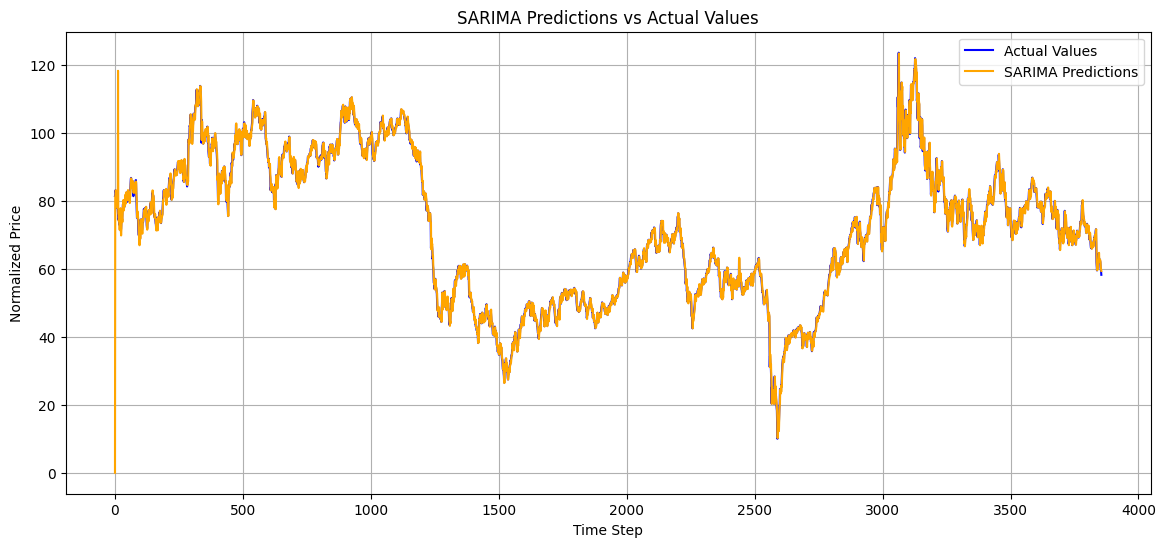

In [ ]:
#TO DO: Plot SARIMA vs actual

plot_predictions(sarima_preds, sarima_actuals, "SARIMA")